In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

In [2]:
# Adjust path if needed (relative to notebook location)
df = pd.read_csv('../data/processed/feature_engineered_data.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (95094, 42)


,payment_count,total_items,total_freight_value,estimated_delivery_days,avg_product_price,avg_product_freight,avg_product_review,avg_product_weight,main_category,total_products_in_order,...,state_RJ,state_RN,state_RO,state_RR,state_RS,state_SC,state_SE,state_SP,state_TO,is_late
0,1,1,13.29,15.625671,59.233333,22.033333,4.444444,650.0,27,1,...,1,0,0,0,0,0,0,0,0,0
1,1,1,19.93,18.546458,239.900000,19.930000,4.000000,30000.0,64,1,...,0,0,0,0,0,0,0,1,0,0
2,1,1,17.87,21.393391,199.000000,18.606667,4.333333,3050.0,55,1,...,0,0,0,0,0,0,0,0,0,0
3,1,1,12.79,11.582928,12.990000,12.790000,4.000000,200.0,63,1,...,0,0,0,0,0,0,0,1,0,0
4,1,1,18.14,40.418160,202.400000,27.052500,3.833333,3750.0,41,1,...,0,0,0,0,0,0,0,1,0,0


In [3]:
target = 'is_late'
X = df.drop(columns=[target])
y = df[target]

print(f"Target distribution:\n{y.value_counts()}")
print(f"\nFeature columns ({X.shape[1]}):\n{X.columns.tolist()}")

Target distribution:
is_late
0    87302
1     7792
Name: count, dtype: int64

Feature columns (41):
['payment_count', 'total_items', 'total_freight_value', 'estimated_delivery_days', 'avg_product_price', 'avg_product_freight', 'avg_product_review', 'avg_product_weight', 'main_category', 'total_products_in_order', 'purchase_month', 'purchase_day', 'purchase_hour', 'is_weekend', 'purchase_quarter', 'state_AL', 'state_AM', 'state_AP', 'state_BA', 'state_CE', 'state_DF', 'state_ES', 'state_GO', 'state_MA', 'state_MG', 'state_MS', 'state_MT', 'state_PA', 'state_PB', 'state_PE', 'state_PI', 'state_PR', 'state_RJ', 'state_RN', 'state_RO', 'state_RR', 'state_RS', 'state_SC', 'state_SE', 'state_SP', 'state_TO']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Train size: (76075, 41)
Test size: (19019, 41)


In [5]:
model = joblib.load('../models/model.pkl')
print("Model loaded successfully")
print(model)

Model loaded successfully
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, ...)


In [6]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Predictions done")

Predictions done


In [7]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['On Time', 'Late']))

Classification Report:
              precision    recall  f1-score   support

     On Time       0.97      0.81      0.88     17461
        Late       0.24      0.68      0.35      1558

    accuracy                           0.80     19019
   macro avg       0.60      0.74      0.62     19019
weighted avg       0.91      0.80      0.84     19019



In [8]:
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {roc_auc:.4f}")

ROC AUC Score: 0.8165


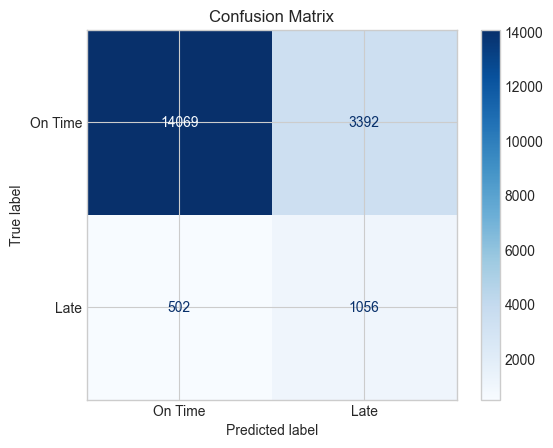

In [9]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On Time', 'Late'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

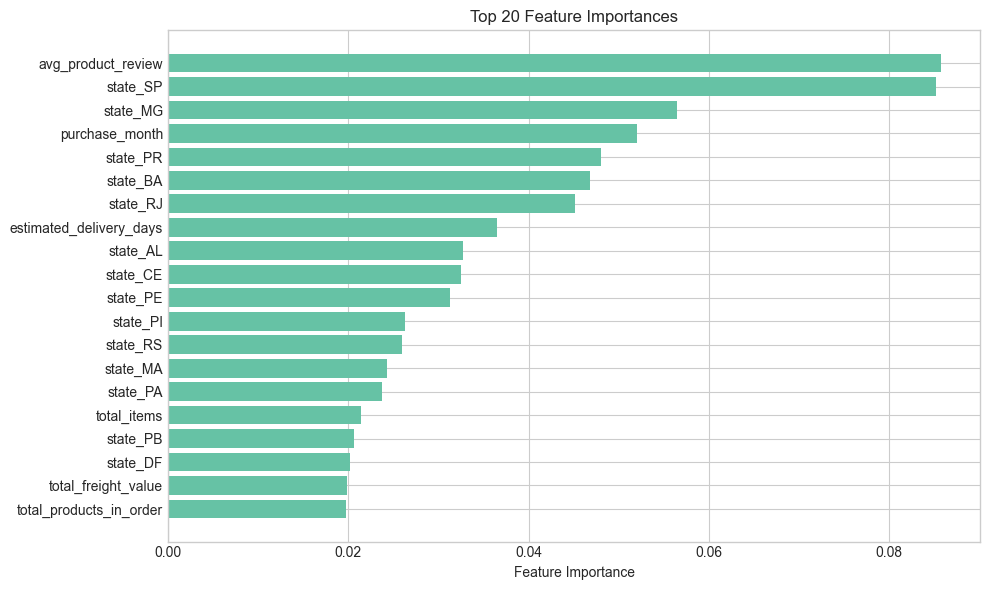

In [11]:
if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
    feature_names = X.columns
    indices = np.argsort(importances)[::-1][:20]
    
    plt.figure(figsize=(10,6))
    plt.barh(range(len(indices)), importances[indices], align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.gca().invert_yaxis()
    plt.xlabel('Feature Importance')
    plt.title('Top 20 Feature Importances')
    plt.tight_layout()
    plt.show()
else:
    print("Model has no feature_importances_ attribute")

In [13]:
# Look at misclassified examples
misclassified = X_test[y_test != y_pred].copy()
misclassified['true'] = y_test[y_test != y_pred]
misclassified['pred'] = y_pred[y_test != y_pred]

print(f"Number of misclassified: {len(misclassified)}")
misclassified.head()

Number of misclassified: 3894


,payment_count,total_items,total_freight_value,estimated_delivery_days,avg_product_price,avg_product_freight,avg_product_review,avg_product_weight,main_category,total_products_in_order,...,state_RN,state_RO,state_RR,state_RS,state_SC,state_SE,state_SP,state_TO,true,pred
72600,1,1,14.52,22.446620,16.305068,15.221918,4.164384,200.0,73,1,...,0,0,0,0,0,0,0,0,0,1
33444,1,1,23.27,22.640417,104.500000,21.055000,4.500000,3300.0,46,1,...,0,0,0,0,0,0,0,0,0,1
65448,2,1,34.15,29.072766,15.788889,12.965778,3.500000,200.0,8,1,...,0,0,0,0,0,0,0,0,0,1
14718,1,1,14.24,22.984005,69.000000,13.928438,3.312500,107.0,45,1,...,0,0,0,0,0,0,0,0,0,1
57150,1,1,22.27,27.655266,84.367486,16.232077,3.464865,180.0,45,1,...,0,0,0,0,0,0,0,0,0,1


In [16]:
# Get predictions
y_pred = model.predict(X_test)

# Build confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Total actual orders in test set
total_actual_on_time = tn + fp   # actually not late
total_actual_late   = fn + tp   # actually late

# Percentages (out of actual class)
tn_rate = tn / total_actual_on_time * 100   # % of on‑time orders we correctly predicted
fp_rate = fp / total_actual_on_time * 100   # % of on‑time orders we wrongly said would be late
fn_rate = fn / total_actual_late * 100      # % of late orders we missed
tp_rate = tp / total_actual_late * 100      # % of late orders we caught

print("===== Confusion Matrix Explained =====")
print()
print("👉 Out of all orders that were ACTUALLY ON TIME:")
print(f"   ✅ {tn_rate:.1f}% were correctly predicted as ON TIME (we were right).")
print(f"   ❌ {fp_rate:.1f}% were WRONGLY predicted as LATE (false alarm).")
print()
print("👉 Out of all orders that were ACTUALLY LATE:")
print(f"   ✅ {tp_rate:.1f}% were correctly predicted as LATE (we caught the delay).")
print(f"   ❌ {fn_rate:.1f}% were WRONGLY predicted as ON TIME (we missed the delay).")


===== Confusion Matrix Explained =====

👉 Out of all orders that were ACTUALLY ON TIME:
   ✅ 80.6% were correctly predicted as ON TIME (we were right).
   ❌ 19.4% were WRONGLY predicted as LATE (false alarm).

👉 Out of all orders that were ACTUALLY LATE:
   ✅ 67.8% were correctly predicted as LATE (we caught the delay).
   ❌ 32.2% were WRONGLY predicted as ON TIME (we missed the delay).
